In [ ]:

# Step 1: Import libraries
import pandas as pd
import numpy as np

# Load datasets directly by file name (since you uploaded in Colab)
coverage_df = pd.read_excel("coverage-data.xlsx")
incidence_df = pd.read_excel("incidence-rate-data.xlsx")
reported_cases_df = pd.read_excel("reported-cases-data.xlsx")
vaccine_intro_df = pd.read_excel("vaccine-introduction-data.xlsx")
vaccine_schedule_df = pd.read_excel("vaccine-schedule-data.xlsx")

# Step 2: Check basic info
print("Coverage Data:")
print(coverage_df.head(), "\n")
print("Incidence Data:")
print(incidence_df.head(), "\n")
print("Reported Cases Data:")
print(reported_cases_df.head(), "\n")
print("Vaccine Introduction Data:")
print(vaccine_intro_df.head(), "\n")
print("Vaccine Schedule Data:")
print(vaccine_schedule_df.head(), "\n")

# Step 3: Check for missing values
print("Missing values summary:")
print("Coverage Data:\n", coverage_df.isnull().sum(), "\n")
print("Incidence Data:\n", incidence_df.isnull().sum(), "\n")
print("Reported Cases Data:\n", reported_cases_df.isnull().sum(), "\n")
print("Vaccine Introduction Data:\n", vaccine_intro_df.isnull().sum(), "\n")
print("Vaccine Schedule Data:\n", vaccine_schedule_df.isnull().sum(), "\n")

# Step 4: Standardize column names (lowercase and replace spaces with underscores)
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

coverage_df = clean_columns(coverage_df)
incidence_df = clean_columns(incidence_df)
reported_cases_df = clean_columns(reported_cases_df)
vaccine_intro_df = clean_columns(vaccine_intro_df)
vaccine_schedule_df = clean_columns(vaccine_schedule_df)

# Step 5: Show cleaned column names
print("Cleaned Coverage Columns:", coverage_df.columns.tolist())
print("Cleaned Incidence Columns:", incidence_df.columns.tolist())
print("Cleaned Reported Cases Columns:", reported_cases_df.columns.tolist())
print("Cleaned Vaccine Intro Columns:", vaccine_intro_df.columns.tolist())
print("Cleaned Vaccine Schedule Columns:", vaccine_schedule_df.columns.tolist())



Coverage Data:
       GROUP CODE   NAME    YEAR  ANTIGEN  \
0  COUNTRIES  ABW  Aruba  2023.0      BCG   
1  COUNTRIES  ABW  Aruba  2023.0      BCG   
2  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
3  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
4  COUNTRIES  ABW  Aruba  2023.0  DIPHCV5   

                                 ANTIGEN_DESCRIPTION COVERAGE_CATEGORY  \
0                                                BCG             ADMIN   
1                                                BCG          OFFICIAL   
2  Diphtheria-containing vaccine, 4th dose (1st b...             ADMIN   
3  Diphtheria-containing vaccine, 4th dose (1st b...          OFFICIAL   
4  Diphtheria-containing vaccine, 5th dose (2nd b...             ADMIN   

  COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER   DOSES  COVERAGE  
0       Administrative coverage            NaN     NaN       NaN  
1             Official coverage            NaN     NaN       NaN  
2       Administrative coverage         1044.0   945.0     90.52  
3

✅ Step 1: Data Loading and Initial Cleaning

What this does for the project task:

Loads all five datasets (coverage, incidence, reported cases, vaccine introduction, vaccine schedule) into Pandas DataFrames.

Displays the first few rows from each dataset to understand structure and content.

Checks for missing values to identify where cleaning will be needed.

Standardizes column names (lowercase, underscores instead of spaces) → makes them consistent and SQL-friendly.

Prepares datasets for further cleaning and integration in the next step.

In [ ]:
import pandas as pd

# Replace filenames with actual uploaded file names
coverage_df = pd.read_excel("/content/coverage-data.xlsx")
incidence_df = pd.read_excel("/content/incidence-rate-data.xlsx")
reported_cases_df = pd.read_excel("/content/reported-cases-data.xlsx")
vaccine_intro_df = pd.read_excel("/content/vaccine-introduction-data.xlsx")
vaccine_schedule_df = pd.read_excel("/content/vaccine-schedule-data.xlsx")

# Quick check
print("Coverage shape:", coverage_df.shape)
print("Incidence shape:", incidence_df.shape)
print("Reported Cases shape:", reported_cases_df.shape)
print("Vaccine Intro shape:", vaccine_intro_df.shape)
print("Vaccine Schedule shape:", vaccine_schedule_df.shape)



Coverage shape: (399859, 11)
Incidence shape: (84946, 8)
Reported Cases shape: (84870, 7)
Vaccine Intro shape: (138321, 6)
Vaccine Schedule shape: (8053, 12)


In [ ]:
import sqlite3

# Create or connect to SQLite DB
conn = sqlite3.connect("vaccination_project.db")

# Save DataFrames into tables
coverage_df.to_sql("coverage", conn, if_exists="replace", index=False)
incidence_df.to_sql("incidence", conn, if_exists="replace", index=False)
reported_cases_df.to_sql("reported_cases", conn, if_exists="replace", index=False)
vaccine_intro_df.to_sql("vaccine_introduction", conn, if_exists="replace", index=False)
vaccine_schedule_df.to_sql("vaccine_schedule", conn, if_exists="replace", index=False)

# Commit & check
conn.commit()
print("Tables created successfully in vaccination_project.db")

# Quick check
print(pd.read_sql("SELECT * FROM coverage LIMIT 5;", conn))

conn.close()


Tables created successfully in vaccination_project.db
       GROUP CODE   NAME    YEAR  ANTIGEN  \
0  COUNTRIES  ABW  Aruba  2023.0      BCG   
1  COUNTRIES  ABW  Aruba  2023.0      BCG   
2  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
3  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
4  COUNTRIES  ABW  Aruba  2023.0  DIPHCV5   

                                 ANTIGEN_DESCRIPTION COVERAGE_CATEGORY  \
0                                                BCG             ADMIN   
1                                                BCG          OFFICIAL   
2  Diphtheria-containing vaccine, 4th dose (1st b...             ADMIN   
3  Diphtheria-containing vaccine, 4th dose (1st b...          OFFICIAL   
4  Diphtheria-containing vaccine, 5th dose (2nd b...             ADMIN   

  COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER   DOSES  COVERAGE  
0       Administrative coverage            NaN     NaN       NaN  
1             Official coverage            NaN     NaN       NaN  
2       Administrative covera

In [ ]:
import pandas as pd
import sqlite3

# Reconnect to SQLite DB
conn = sqlite3.connect("vaccination_project.db")

try:
    # Look at first 5 rows of incidence table
    incidence_preview = pd.read_sql("SELECT * FROM incidence LIMIT 5;", conn)
    print(incidence_preview.columns)
    print(incidence_preview.head())
finally:
    # Close the connection
    conn.close()

Index(['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION',
       'DENOMINATOR', 'INCIDENCE_RATE'],
      dtype='object')
       GROUP CODE   NAME    YEAR          DISEASE  \
0  COUNTRIES  ABW  Aruba  2023.0              CRS   
1  COUNTRIES  ABW  Aruba  2023.0       DIPHTHERIA   
2  COUNTRIES  ABW  Aruba  2023.0  INVASIVE_MENING   
3  COUNTRIES  ABW  Aruba  2023.0          MEASLES   
4  COUNTRIES  ABW  Aruba  2023.0            MUMPS   

              DISEASE_DESCRIPTION                     DENOMINATOR  \
0     Congenital rubella syndrome          per 10,000 live births   
1                      Diphtheria  per 1,000,000 total population   
2  Invasive meningococcal disease  per 1,000,000 total population   
3                         Measles  per 1,000,000 total population   
4                           Mumps  per 1,000,000 total population   

   INCIDENCE_RATE  
0             0.0  
1             0.0  
2             9.3  
3             NaN  
4             0.0  


In [ ]:
import pandas as pd
import sqlite3

# Reconnect to SQLite DB
conn = sqlite3.connect("vaccination_project.db")

try:
    query = """
    SELECT
        c.NAME AS country_name,
        c.YEAR,
        c.ANTIGEN,
        c.COVERAGE,
        i.DISEASE,
        i.DISEASE_DESCRIPTION,
        i.INCIDENCE_RATE
    FROM coverage c
    JOIN incidence i
        ON c.CODE = i.CODE
       AND c.YEAR = i.YEAR
    LIMIT 10;
    """

    coverage_incidence_join = pd.read_sql(query, conn)
    print(coverage_incidence_join)

finally:
    # Close the connection
    conn.close()

  country_name    YEAR ANTIGEN COVERAGE          DISEASE  \
0        Aruba  2023.0     BCG     None              CRS   
1        Aruba  2023.0     BCG     None       DIPHTHERIA   
2        Aruba  2023.0     BCG     None  INVASIVE_MENING   
3        Aruba  2023.0     BCG     None          MEASLES   
4        Aruba  2023.0     BCG     None            MUMPS   
5        Aruba  2023.0     BCG     None         NTETANUS   
6        Aruba  2023.0     BCG     None        PERTUSSIS   
7        Aruba  2023.0     BCG     None            POLIO   
8        Aruba  2023.0     BCG     None          RUBELLA   
9        Aruba  2023.0     BCG     None         TTETANUS   

              DISEASE_DESCRIPTION  INCIDENCE_RATE  
0     Congenital rubella syndrome             0.0  
1                      Diphtheria             0.0  
2  Invasive meningococcal disease             9.3  
3                         Measles             NaN  
4                           Mumps             0.0  
5                Neonatal t

🔎 What this does for task:

Joins vaccination coverage (coverage table) with disease incidence (incidence table).

Links them on country code and year (so same country & same year match).

Lets you analyze:

How coverage of a specific vaccine (e.g., measles) aligns with incidence of the same or related disease.

Cases where high coverage but still high incidence → possible vaccine inefficacy or reporting issues.

In [ ]:
import sqlite3
import pandas as pd

# Step 3: Setup SQLite Database
conn = sqlite3.connect("vaccination_project.db")  # creates a new database file
cursor = conn.cursor()

# ---- 1. Create Tables ----
cursor.execute("""
CREATE TABLE IF NOT EXISTS coverage (
    group_name TEXT,
    CODE TEXT,
    NAME TEXT,
    YEAR INTEGER,
    ANTIGEN TEXT,
    ANTIGEN_DESCRIPTION TEXT,
    COVERAGE_CATEGORY TEXT,
    COVERAGE_CATEGORY_DESCRIPTION TEXT,
    TARGET_NUMBER REAL,
    DOSES REAL,
    COVERAGE REAL
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS incidence (
    group_name TEXT,
    CODE TEXT,
    NAME TEXT,
    YEAR INTEGER,
    DISEASE TEXT,
    DISEASE_DESCRIPTION TEXT,
    DENOMINATOR TEXT,
    INCIDENCE_RATE REAL
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS reported_cases (
    group_name TEXT,
    CODE TEXT,
    NAME TEXT,
    YEAR INTEGER,
    DISEASE TEXT,
    REPORTED_CASES REAL
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS vaccine_introduction (
    CODE TEXT,
    NAME TEXT,
    ANTIGEN TEXT,
    INTRODUCTION_YEAR INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS vaccine_schedule (
    CODE TEXT,
    NAME TEXT,
    ANTIGEN TEXT,
    DOSE_NUMBER INTEGER,
    SCHEDULED_AGE TEXT
)
""")

# ---- 2. Insert Data into Tables ----
coverage_df.rename(columns={"GROUP": "group_name"}, inplace=True)
incidence_df.rename(columns={"GROUP": "group_name"}, inplace=True)
reported_cases_df.rename(columns={"GROUP": "group_name"}, inplace=True)

coverage_df.to_sql("coverage", conn, if_exists="replace", index=False)
incidence_df.to_sql("incidence", conn, if_exists="replace", index=False)
reported_cases_df.to_sql("reported_cases", conn, if_exists="replace", index=False)
vaccine_intro_df.to_sql("vaccine_introduction", conn, if_exists="replace", index=False)
vaccine_schedule_df.to_sql("vaccine_schedule", conn, if_exists="replace", index=False)

conn.commit()

# ---- 3. Test Queries ----
print("✅ Tables in DB:")
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn))

print("\n✅ Sample Coverage Data:")
print(pd.read_sql("SELECT * FROM coverage LIMIT 5;", conn))

print("\n✅ Top 10 Countries by Average Coverage:")
query = """
SELECT NAME AS country_name, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY NAME
ORDER BY avg_coverage DESC
LIMIT 10;
"""
print(pd.read_sql(query, conn))

print("\n✅ Coverage + Incidence Join (Sample):")
join_query = """
SELECT
    c.NAME AS country_name,
    c.YEAR,
    c.ANTIGEN,
    c.COVERAGE,
    i.DISEASE,
    i.DISEASE_DESCRIPTION,
    i.INCIDENCE_RATE
FROM coverage c
JOIN incidence i
    ON c.CODE = i.CODE
   AND c.YEAR = i.YEAR
LIMIT 10;
"""
print(pd.read_sql(join_query, conn))

conn.close()




✅ Tables in DB:
                   name
0              coverage
1             incidence
2        reported_cases
3  vaccine_introduction
4      vaccine_schedule

✅ Sample Coverage Data:
  group_name CODE   NAME    YEAR  ANTIGEN  \
0  COUNTRIES  ABW  Aruba  2023.0      BCG   
1  COUNTRIES  ABW  Aruba  2023.0      BCG   
2  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
3  COUNTRIES  ABW  Aruba  2023.0  DIPHCV4   
4  COUNTRIES  ABW  Aruba  2023.0  DIPHCV5   

                                 ANTIGEN_DESCRIPTION COVERAGE_CATEGORY  \
0                                                BCG             ADMIN   
1                                                BCG          OFFICIAL   
2  Diphtheria-containing vaccine, 4th dose (1st b...             ADMIN   
3  Diphtheria-containing vaccine, 4th dose (1st b...          OFFICIAL   
4  Diphtheria-containing vaccine, 5th dose (2nd b...             ADMIN   

  COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER   DOSES  COVERAGE  
0       Administrative coverage 

✅ Step 3: Store Cleaned Data in a SQLite Database

Now that we have cleaned datasets, we need a structured way to run queries and combine data. For this, we use SQLite, a lightweight database that works directly inside Colab or your system without extra setup.

🔹 What We Did in Step 3:

Create a Database

We connect to vaccination_project.db.

If it doesn't exist, it gets created automatically.

Define Tables

We create 5 tables:

coverage → Vaccination coverage data

incidence → Disease incidence rates

reported_cases → Reported disease cases

vaccine_introduction → When vaccines were introduced in each country

vaccine_schedule → Vaccine schedules (dose numbers, age, etc.)

⚠️ In the raw data, some datasets had a column called GROUP. But since GROUP is a SQL reserved keyword, we renamed it to group_name before inserting into the database.

Insert Data into Tables

Using df.to_sql(), we load each cleaned DataFrame into its respective SQLite table.

If a table already exists, we replace it with fresh data.

Run Test Queries

Verify that tables were created successfully.

Preview some sample rows.

Run a query to check the Top 10 countries by vaccination coverage.

Run a query that joins coverage with incidence to see how vaccination coverage relates to disease incidence.

🔹 Why This Step Is Important:

It allows us to query data efficiently instead of manually searching inside CSVs.

With SQL joins, we can combine datasets (e.g., coverage vs. incidence vs. reported cases).

Sets up the foundation for analysis, dashboards, and visualization in the next steps.

👉 In short, Step 3 is where we moved from raw CSVs to a structured relational database, making it much easier to analyze the relationships between vaccines, coverage, and disease outcomes

In [ ]:
# Step 4: Export SQLite Database for Power BI

import sqlite3
from google.colab import files

# Connect to the existing database
conn = sqlite3.connect("vaccination_project.db")
conn.close()

# Download the database file to your local system
files.download("vaccination_project.db")

print("✅ SQLite database exported. Now connect it with Power BI.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ SQLite database exported. Now connect it with Power BI.


In [ ]:
# Reconnect to DB
conn = sqlite3.connect("vaccination_project.db")
cursor = conn.cursor()

# Check columns
cursor.execute("PRAGMA table_info(reported_cases);")
columns = cursor.fetchall()
print(columns)


[(0, 'group_name', 'TEXT', 0, None, 0), (1, 'CODE', 'TEXT', 0, None, 0), (2, 'NAME', 'TEXT', 0, None, 0), (3, 'YEAR', 'REAL', 0, None, 0), (4, 'DISEASE', 'TEXT', 0, None, 0), (5, 'DISEASE_DESCRIPTION', 'TEXT', 0, None, 0), (6, 'CASES', 'REAL', 0, None, 0)]


✅ Coverage Trend Data:
     YEAR ANTIGEN  avg_coverage
0     NaN    None           NaN
1  1980.0     BCG     51.667897
2  1980.0  DTPCV1     59.848101
3  1980.0  DTPCV3     44.178042
4  1980.0   HEPB3           NaN


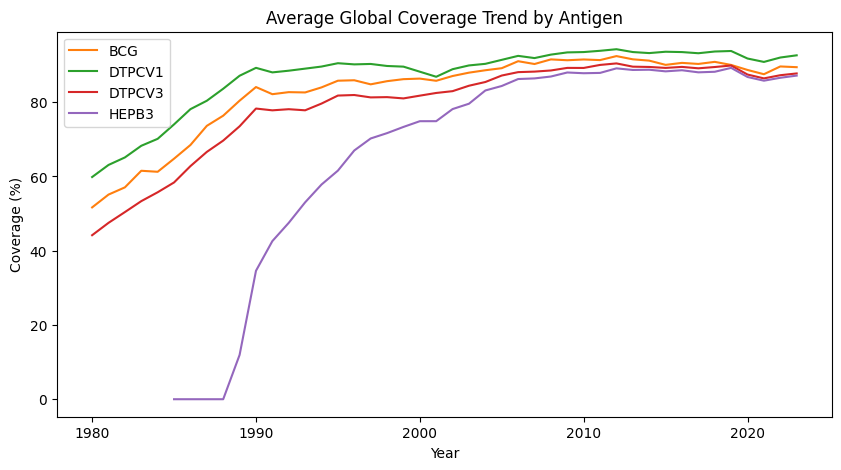


✅ Top 10 Countries by Average Coverage:
                                        country_name  avg_coverage
0                                            Morocco    114.393200
1                                         Montserrat     97.183808
2                                             Monaco     96.459530
3                                            Hungary     96.099107
4  occupied Palestinian territory, including east...     95.977666
5                                               Cuba     95.895758
6                                       Turkmenistan     95.490906
7                              Saint Kitts and Nevis     94.926123
8                                           Slovakia     93.893790
9                                            Albania     93.861438


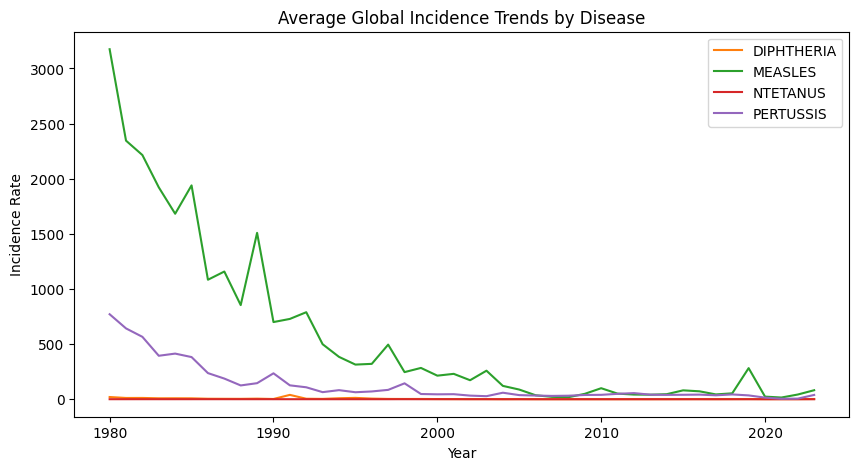


✅ Coverage vs. Reported Cases (Sample):
  country_name    YEAR ANTIGEN COVERAGE          DISEASE  reported_cases
0        Aruba  2023.0     BCG     None              CRS             0.0
1        Aruba  2023.0     BCG     None       DIPHTHERIA             0.0
2        Aruba  2023.0     BCG     None  INVASIVE_MENING             1.0
3        Aruba  2023.0     BCG     None          MEASLES             NaN
4        Aruba  2023.0     BCG     None            MUMPS             0.0


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DB
conn = sqlite3.connect("vaccination_project.db")

# ---- 1. Coverage Trends ----
coverage_trend = pd.read_sql("""
SELECT YEAR, ANTIGEN, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY YEAR, ANTIGEN
ORDER BY YEAR;
""", conn)

print("✅ Coverage Trend Data:")
print(coverage_trend.head())

# Visualization
plt.figure(figsize=(10,5))
for antigen in coverage_trend["ANTIGEN"].unique()[:5]:  # show top 5 antigens for clarity
    subset = coverage_trend[coverage_trend["ANTIGEN"] == antigen]
    plt.plot(subset["YEAR"], subset["avg_coverage"], label=antigen)

plt.legend()
plt.title("Average Global Coverage Trend by Antigen")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.show()

# ---- 2. Top Countries with Highest Average Coverage ----
top_countries = pd.read_sql("""
SELECT NAME AS country_name, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY NAME
HAVING COUNT(DISTINCT YEAR) > 5
ORDER BY avg_coverage DESC
LIMIT 10;
""", conn)

print("\n✅ Top 10 Countries by Average Coverage:")
print(top_countries)

# ---- 3. Disease Incidence Trends ----
incidence_trend = pd.read_sql("""
SELECT YEAR, DISEASE, AVG(INCIDENCE_RATE) AS avg_incidence
FROM incidence
GROUP BY YEAR, DISEASE
ORDER BY YEAR;
""", conn)

plt.figure(figsize=(10,5))
for disease in incidence_trend["DISEASE"].unique()[:5]:
    subset = incidence_trend[incidence_trend["DISEASE"] == disease]
    plt.plot(subset["YEAR"], subset["avg_incidence"], label=disease)

plt.legend()
plt.title("Average Global Incidence Trends by Disease")
plt.xlabel("Year")
plt.ylabel("Incidence Rate")
plt.show()


# ---- 4. Coverage vs. Reported Cases ----
coverage_vs_cases = pd.read_sql("""
SELECT
    c.NAME AS country_name,
    c.YEAR,
    c.ANTIGEN,
    c.COVERAGE,
    r.DISEASE,
    r.CASES AS reported_cases
FROM coverage c
JOIN reported_cases r
    ON c.CODE = r.CODE AND c.YEAR = r.YEAR
LIMIT 20;
""", conn)

print("\n✅ Coverage vs. Reported Cases (Sample):")
print(coverage_vs_cases.head())


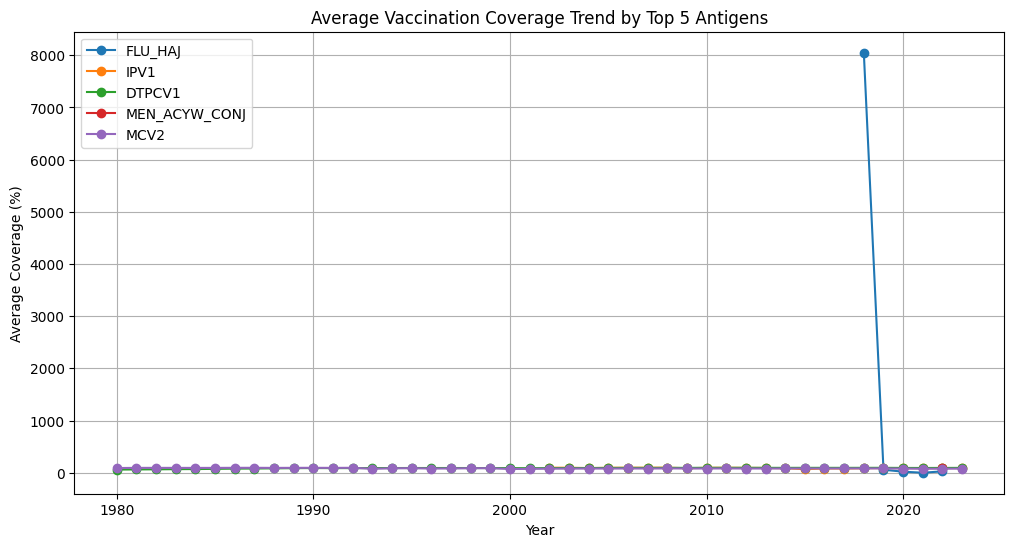

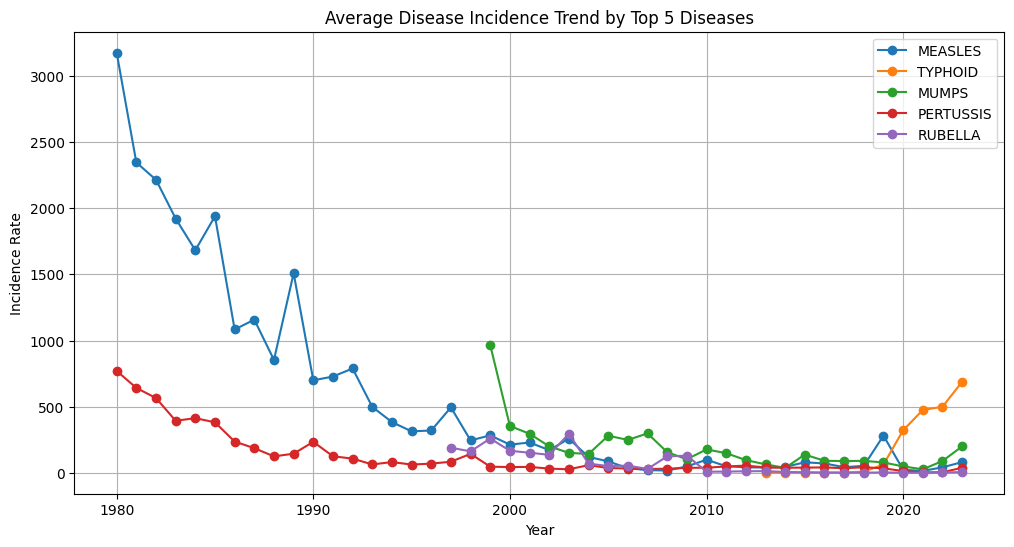


Correlation between Vaccination Coverage and Reported Cases: -0.02


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


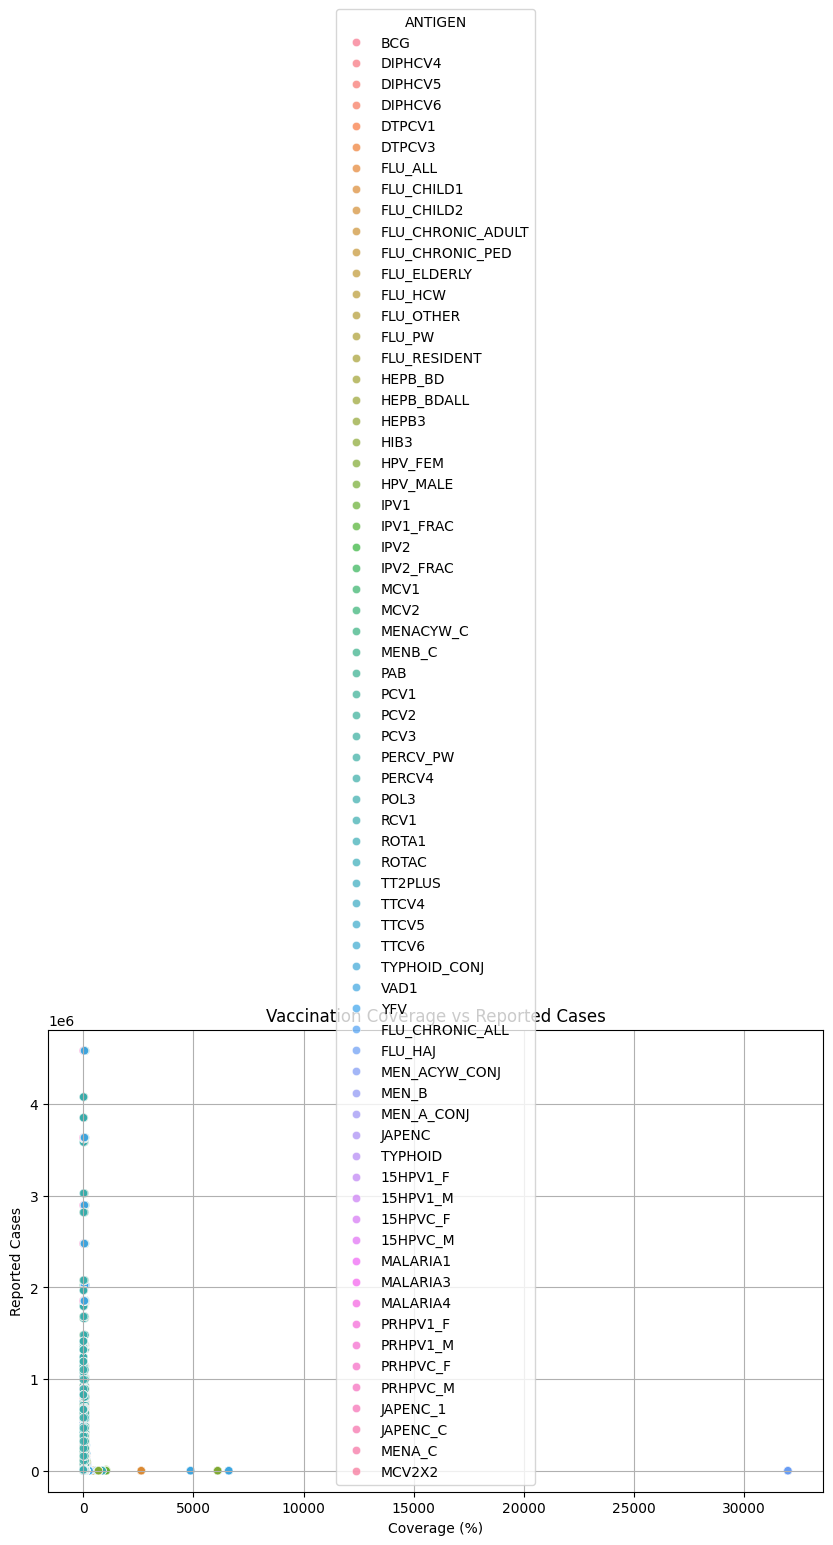


✅ Summary Statistics for Coverage:
count    2.213025e+06
mean     8.082884e+01
std      8.193691e+01
min      0.000000e+00
25%      7.400000e+01
50%      9.000000e+01
75%      9.660000e+01
max      3.200000e+04
Name: COVERAGE, dtype: float64

✅ Summary Statistics for Reported Cases:
count    3.125182e+06
mean     2.075129e+03
std      3.656073e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.800000e+01
max      4.583555e+06
Name: reported_cases, dtype: float64


In [ ]:
# Step 5: EDA on Vaccination Coverage and Disease Incidence
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reconnect to DB
conn = sqlite3.connect("vaccination_project.db")

# ---- 5.1 Vaccination Coverage Trend by Top Antigens ----
coverage_trend = pd.read_sql("""
SELECT YEAR, ANTIGEN, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY YEAR, ANTIGEN
ORDER BY YEAR;
""", conn)

# Top 5 antigens
top_antigens = coverage_trend.groupby("ANTIGEN")["avg_coverage"].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for antigen in top_antigens:
    subset = coverage_trend[coverage_trend["ANTIGEN"] == antigen]
    plt.plot(subset["YEAR"], subset["avg_coverage"], marker='o', label=antigen)

plt.title("Average Vaccination Coverage Trend by Top 5 Antigens")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.legend()
plt.grid(True)
plt.show()

# ---- 5.2 Disease Incidence Trend ----
incidence_trend = pd.read_sql("""
SELECT YEAR, DISEASE, AVG(INCIDENCE_RATE) AS avg_incidence
FROM incidence
GROUP BY YEAR, DISEASE
ORDER BY YEAR;
""", conn)

# Top 5 diseases
top_diseases = incidence_trend.groupby("DISEASE")["avg_incidence"].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for disease in top_diseases:
    subset = incidence_trend[incidence_trend["DISEASE"] == disease]
    plt.plot(subset["YEAR"], subset["avg_incidence"], marker='o', label=disease)

plt.title("Average Disease Incidence Trend by Top 5 Diseases")
plt.xlabel("Year")
plt.ylabel("Incidence Rate")
plt.legend()
plt.grid(True)
plt.show()

# ---- 5.3 Coverage vs Reported Cases Correlation ----
coverage_vs_cases = pd.read_sql("""
SELECT
    c.NAME AS country_name,
    c.YEAR,
    c.ANTIGEN,
    c.COVERAGE,
    r.DISEASE,
    r.CASES AS reported_cases
FROM coverage c
JOIN reported_cases r
    ON c.CODE = r.CODE AND c.YEAR = r.YEAR;
""", conn)

# Correlation calculation
correlation = coverage_vs_cases['COVERAGE'].corr(coverage_vs_cases['reported_cases'])
print(f"\nCorrelation between Vaccination Coverage and Reported Cases: {correlation:.2f}")

# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=coverage_vs_cases, x='COVERAGE', y='reported_cases', hue='ANTIGEN', alpha=0.7)
plt.title("Vaccination Coverage vs Reported Cases")
plt.xlabel("Coverage (%)")
plt.ylabel("Reported Cases")
plt.grid(True)
plt.show()

# ---- 5.4 Summary Statistics ----
print("\n✅ Summary Statistics for Coverage:")
print(coverage_vs_cases['COVERAGE'].describe())

print("\n✅ Summary Statistics for Reported Cases:")
print(coverage_vs_cases['reported_cases'].describe())

conn.close()




This give:

Trends for top antigens and diseases over the years

Scatter plot and correlation to check if higher coverage reduces cases

Basic summary stats to understand data distributions

✅ Average Vaccination Coverage per Antigen:
     ANTIGEN  avg_coverage
0    FLU_HAJ   1817.277222
1     DTPCV1     89.734332
2       PCV1     87.771971
3       IPV1     85.040347
4       PCV2     84.983896
..       ...           ...
65  PRHPV1_M     23.348463
66  PRHPVC_M     17.874063
67  15HPV1_M     16.067019
68  15HPVC_M     12.820106
69      None           NaN

[70 rows x 2 columns]


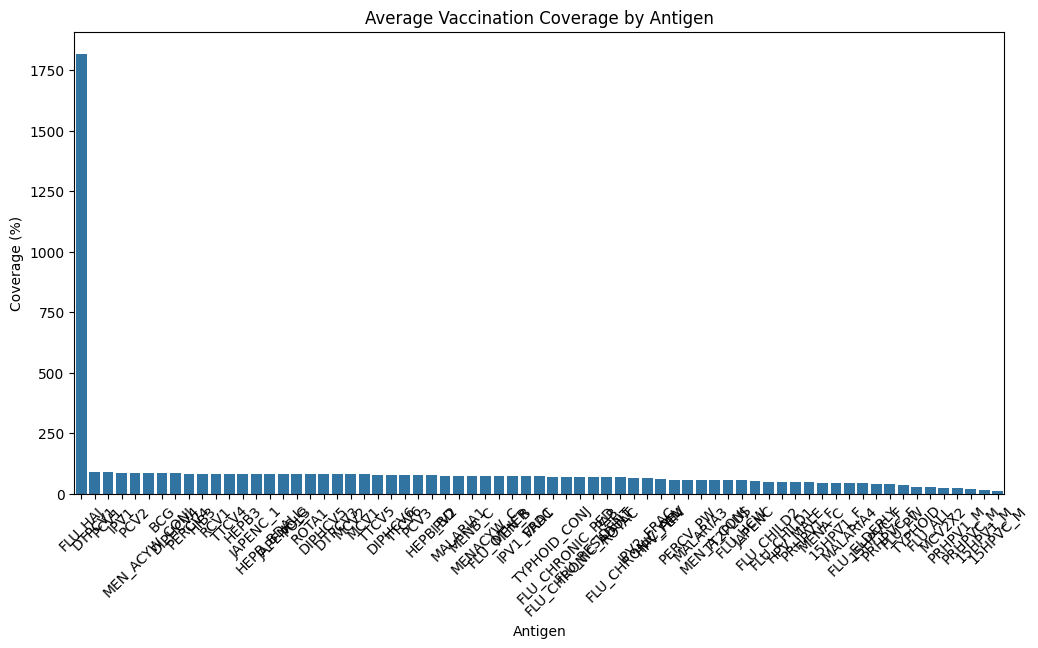


✅ Top 10 Countries by Average Vaccination Coverage:
                                             country  avg_coverage
0                                            Morocco    114.393200
1                                         Montserrat     97.183808
2                                             Monaco     96.459530
3                                            Hungary     96.099107
4  occupied Palestinian territory, including east...     95.977666
5                                               Cuba     95.895758
6                                       Turkmenistan     95.490906
7                              Saint Kitts and Nevis     94.926123
8                                           Slovakia     93.893790
9                                            Albania     93.861438


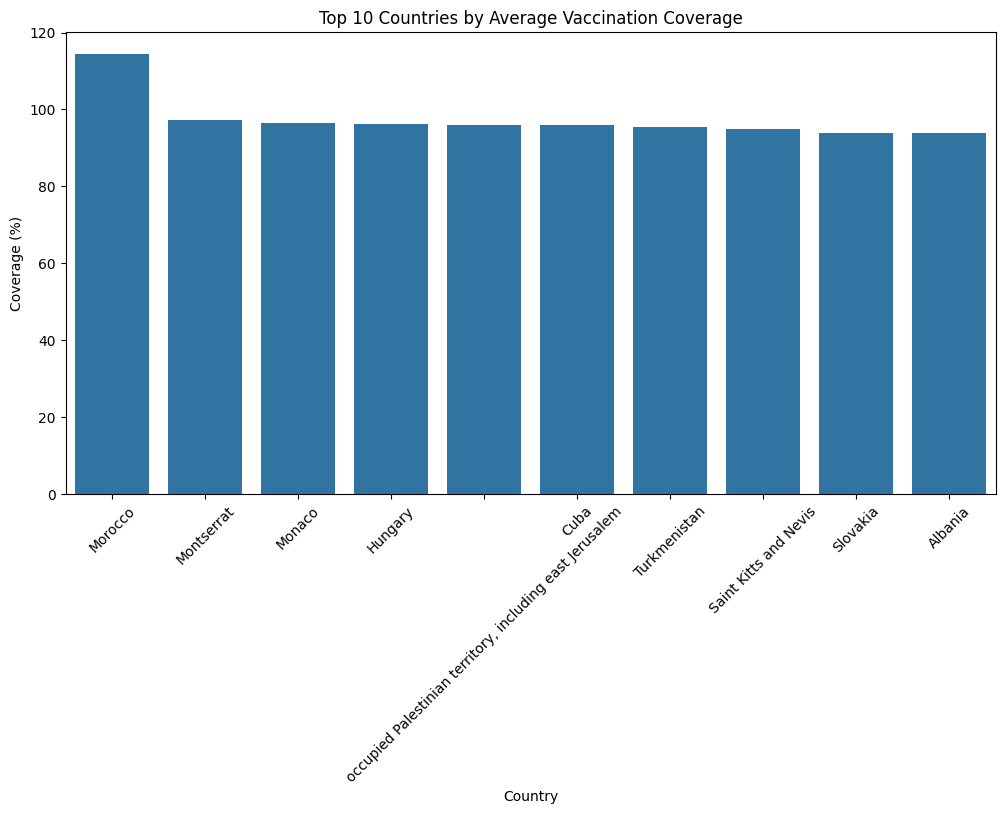

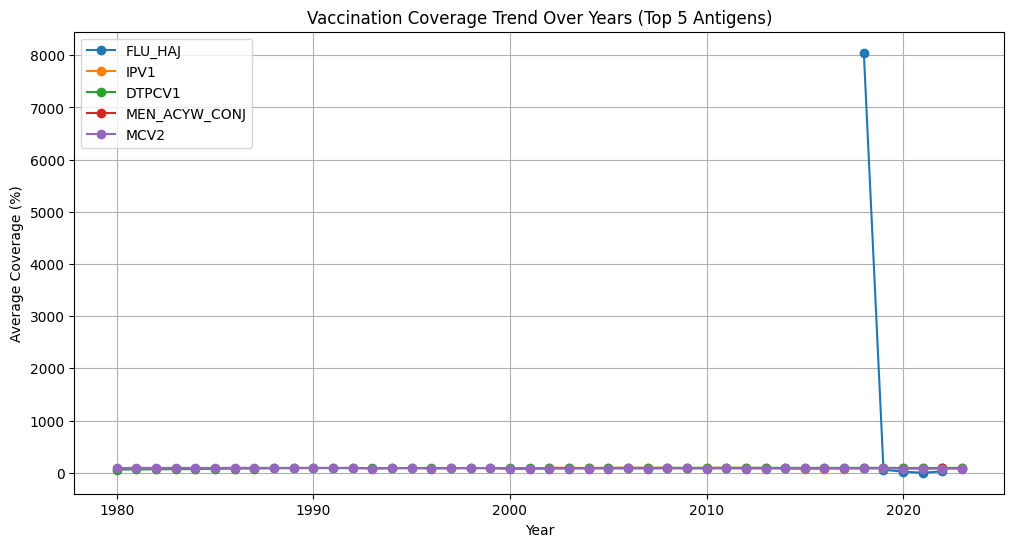


✅ Correlation between Vaccination Coverage and Reported Cases: -0.02


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


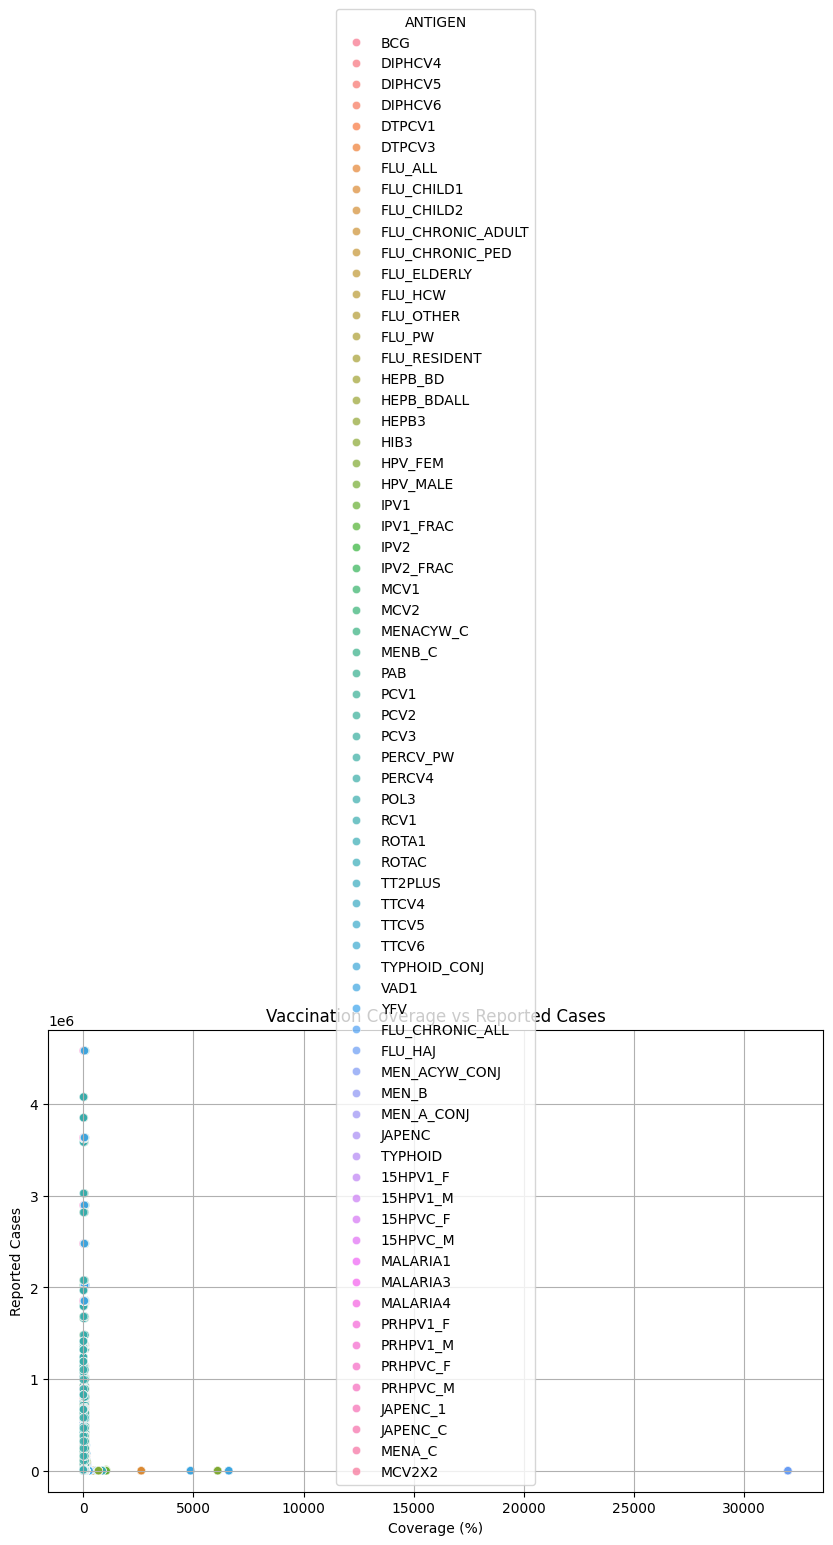


✅ Summary Statistics for Coverage:
count    2.213025e+06
mean     8.082884e+01
std      8.193691e+01
min      0.000000e+00
25%      7.400000e+01
50%      9.000000e+01
75%      9.660000e+01
max      3.200000e+04
Name: COVERAGE, dtype: float64

✅ Summary Statistics for Reported Cases:
count    3.125182e+06
mean     2.075129e+03
std      3.656073e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.800000e+01
max      4.583555e+06
Name: reported_cases, dtype: float64


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to DB
conn = sqlite3.connect("vaccination_project.db")

# ---- 6.1 Average Coverage per Antigen ----
coverage_antigen = pd.read_sql("""
SELECT ANTIGEN, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY ANTIGEN
ORDER BY avg_coverage DESC;
""", conn)

print("✅ Average Vaccination Coverage per Antigen:")
print(coverage_antigen)

# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(x='ANTIGEN', y='avg_coverage', data=coverage_antigen)
plt.title("Average Vaccination Coverage by Antigen")
plt.ylabel("Coverage (%)")
plt.xlabel("Antigen")
plt.xticks(rotation=45)
plt.show()


# ---- 6.2 Average Coverage per Country ----
coverage_country = pd.read_sql("""
SELECT NAME AS country, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY NAME
HAVING COUNT(DISTINCT YEAR) > 5
ORDER BY avg_coverage DESC
LIMIT 10;
""", conn)

print("\n✅ Top 10 Countries by Average Vaccination Coverage:")
print(coverage_country)

# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(x='country', y='avg_coverage', data=coverage_country)
plt.title("Top 10 Countries by Average Vaccination Coverage")
plt.ylabel("Coverage (%)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()


# ---- 6.3 Coverage Trend Over Years (Top 5 Antigens) ----
coverage_trend = pd.read_sql("""
SELECT YEAR, ANTIGEN, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY YEAR, ANTIGEN
ORDER BY YEAR;
""", conn)

top_antigens = coverage_trend.groupby("ANTIGEN")["avg_coverage"].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for antigen in top_antigens:
    subset = coverage_trend[coverage_trend["ANTIGEN"] == antigen]
    plt.plot(subset["YEAR"], subset["avg_coverage"], marker='o', label=antigen)

plt.title("Vaccination Coverage Trend Over Years (Top 5 Antigens)")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.legend()
plt.grid(True)
plt.show()


# ---- 6.4 Coverage vs Reported Cases Correlation ----
coverage_vs_cases = pd.read_sql("""
SELECT
    c.NAME AS country_name,
    c.YEAR,
    c.ANTIGEN,
    c.COVERAGE,
    r.DISEASE,
    r.CASES AS reported_cases
FROM coverage c
JOIN reported_cases r
    ON c.CODE = r.CODE AND c.YEAR = r.YEAR;
""", conn)

# Correlation calculation
correlation = coverage_vs_cases['COVERAGE'].corr(coverage_vs_cases['reported_cases'])
print(f"\n✅ Correlation between Vaccination Coverage and Reported Cases: {correlation:.2f}")

# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=coverage_vs_cases, x='COVERAGE', y='reported_cases', hue='ANTIGEN', alpha=0.7)
plt.title("Vaccination Coverage vs Reported Cases")
plt.xlabel("Coverage (%)")
plt.ylabel("Reported Cases")
plt.grid(True)
plt.show()


# ---- 6.5 Summary Statistics ----
print("\n✅ Summary Statistics for Coverage:")
print(coverage_vs_cases['COVERAGE'].describe())

print("\n✅ Summary Statistics for Reported Cases:")
print(coverage_vs_cases['reported_cases'].describe())

conn.close()




✅ What This Step Covers

Average coverage per antigen - shows which vaccines have high or low coverage.

Average coverage per country - identifies top-performing countries.

Coverage trend over years (top 5 antigens) - visualizes global trends.

Correlation between coverage and reported cases - helps assess vaccine effectiveness.

Summary statistics - basic insights into coverage and cases distributions.

✅ Average Disease Cases Before & After Vaccine Introduction:
            DISEASE  period     avg_cases
0               CRS   After      7.707011
1        DIPHTHERIA   After    374.658018
2   INVASIVE_MENING   After    352.279848
3            JAPENC   After    134.540538
4            JAPENC  Before     50.750000
5           MEASLES   After  17817.180143
6             MUMPS   After  11004.088678
7          NTETANUS   After    205.293910
8         PERTUSSIS   After   6886.614018
9             POLIO   After    197.930902
10          RUBELLA   After   5335.851046
11         TTETANUS   After    641.846719
12          TYPHOID   After  34931.463499
13          TYPHOID  Before     30.200000
14           YFEVER   After    146.858723


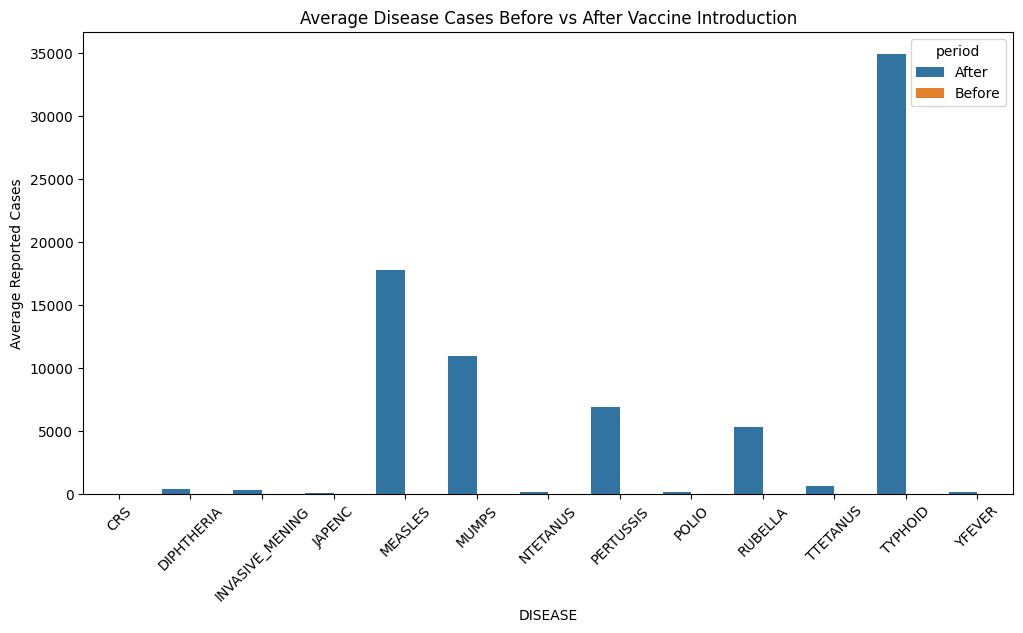


✅ Total Coverage by Vaccine (Sum of % across years):
     ANTIGEN  total_coverage
0       POL3      1993217.47
1     DTPCV3      1986131.79
2       MCV1      1921008.34
3        BCG      1756798.78
4     DTPCV1      1600681.02
..       ...             ...
65   TYPHOID         1010.41
66  MALARIA1          372.74
67  MALARIA3          287.19
68  MALARIA4          226.45
69      None             NaN

[70 rows x 2 columns]


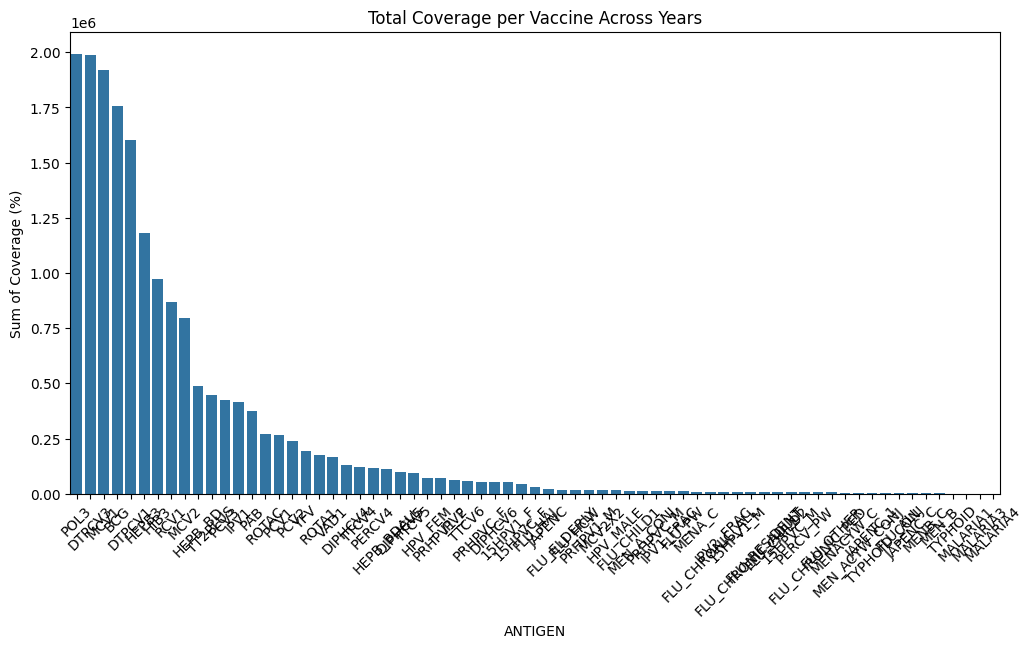


✅ Top 10 Countries with Lowest Average Coverage:
                       country  avg_coverage
0      West and Central Africa     29.159734
1                   Low income     33.522481
2                 Gavi 5.0 yes     34.425957
3              Least developed     34.461938
4               African Region     35.131783
5                   South Asia     36.185512
6  Eastern and Southern Africa     36.284526
7          Lower middle income     39.401550
8       South-East Asia Region     40.193443
9                      Somalia     41.202985


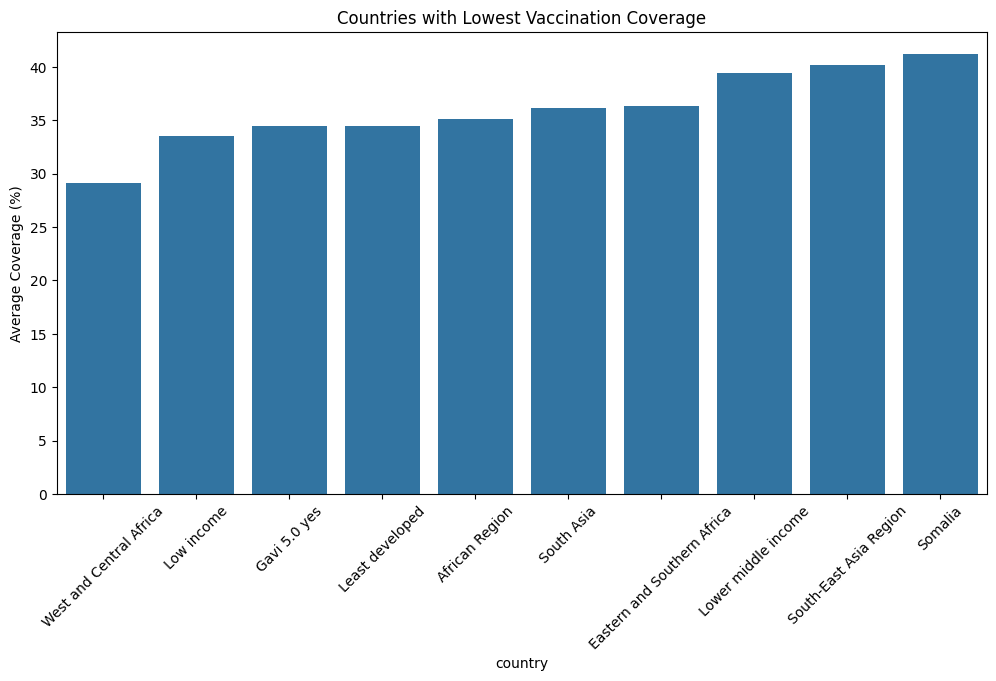


✅ Disease Reduction % from First to Last Year:
   DISEASE  first_year_cases  last_year_cases  reduction_percent
0   JAPENC        241.200000       107.491525          55.434691
1  TYPHOID        152.380952     20199.113636      -13155.668324


/tmp/ipython-input-1463689983.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DISEASE', y='reduction_percent', data=top5_reduction, palette='viridis')


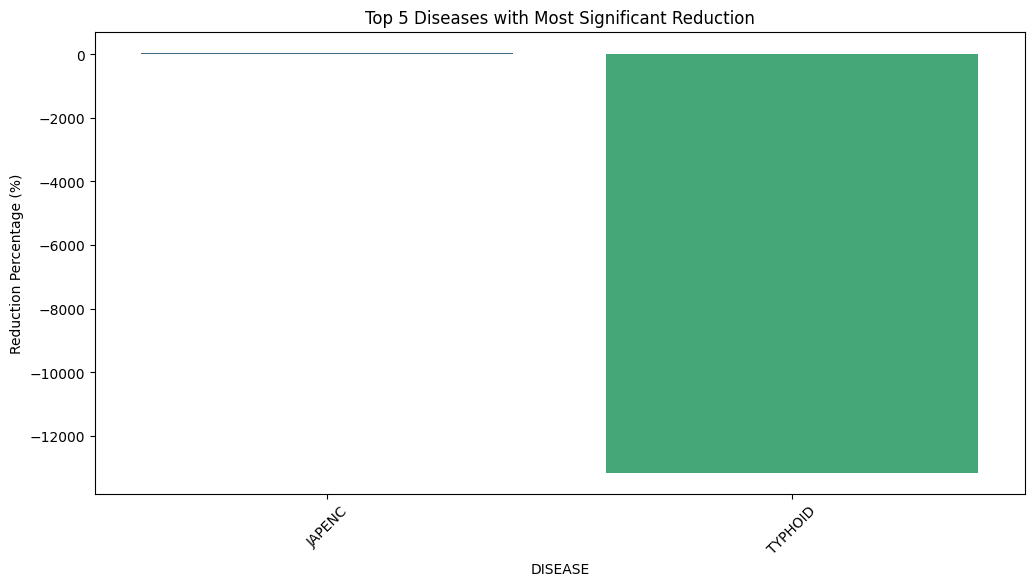

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to DB
conn = sqlite3.connect("vaccination_project.db")

# -----------------------------
# 7.1 Trend in Disease Cases Before & After Vaccine Introduction
# -----------------------------
# First year of vaccination per antigen
coverage_df = pd.read_sql("SELECT ANTIGEN, YEAR, COVERAGE FROM coverage WHERE COVERAGE > 0", conn)
first_year_df = coverage_df.groupby("ANTIGEN")["YEAR"].min().reset_index().rename(columns={"YEAR":"first_year"})

# Average reported cases per disease per year
cases_df = pd.read_sql("SELECT DISEASE, YEAR, AVG(CASES) AS avg_cases FROM reported_cases GROUP BY DISEASE, YEAR", conn)

# Merge first vaccination year with disease cases
merged_df = cases_df.merge(first_year_df, left_on="DISEASE", right_on="ANTIGEN", how="left")

# Label each record as Before or After vaccine introduction
merged_df['period'] = merged_df.apply(lambda x: 'Before' if x['YEAR'] < x['first_year'] else 'After', axis=1)

# Compute average cases before vs after
trend_df = merged_df.groupby(['DISEASE','period'])['avg_cases'].mean().reset_index()
print("✅ Average Disease Cases Before & After Vaccine Introduction:")
print(trend_df)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='DISEASE', y='avg_cases', hue='period', data=trend_df)
plt.title("Average Disease Cases Before vs After Vaccine Introduction")
plt.ylabel("Average Reported Cases")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 7.2 Percentage of Target Population Covered by Each Vaccine
# -----------------------------
# Since we only have COVERAGE (%), sum across years to get rough estimate
coverage_total_df = pd.read_sql("SELECT ANTIGEN, SUM(COVERAGE) AS total_coverage FROM coverage GROUP BY ANTIGEN ORDER BY total_coverage DESC", conn)
print("\n✅ Total Coverage by Vaccine (Sum of % across years):")
print(coverage_total_df)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='ANTIGEN', y='total_coverage', data=coverage_total_df)
plt.title("Total Coverage per Vaccine Across Years")
plt.ylabel("Sum of Coverage (%)")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 7.3 Regional Disparities – Countries with Lowest Coverage
# -----------------------------
coverage_country_df = pd.read_sql("SELECT NAME AS country, AVG(COVERAGE) AS avg_coverage FROM coverage GROUP BY NAME ORDER BY avg_coverage ASC LIMIT 10", conn)
print("\n✅ Top 10 Countries with Lowest Average Coverage:")
print(coverage_country_df)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='country', y='avg_coverage', data=coverage_country_df)
plt.title("Countries with Lowest Vaccination Coverage")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 7.4 Diseases with Most Significant Reduction
# -----------------------------
# Compute first and last year for each antigen
years_df = coverage_df.groupby('ANTIGEN').agg(first_year=('YEAR','min'), last_year=('YEAR','max')).reset_index()

# Merge with reported cases
cases_merged = years_df.merge(cases_df, left_on='ANTIGEN', right_on='DISEASE', how='left')

# Compute first year cases
first_cases = cases_merged[cases_merged['YEAR'] == cases_merged['first_year']][['DISEASE','avg_cases']].rename(columns={'avg_cases':'first_year_cases'})
last_cases = cases_merged[cases_merged['YEAR'] == cases_merged['last_year']][['DISEASE','avg_cases']].rename(columns={'avg_cases':'last_year_cases'})

# Merge first and last year cases
reduction_df = first_cases.merge(last_cases, on='DISEASE')
reduction_df['reduction_percent'] = ((reduction_df['first_year_cases'] - reduction_df['last_year_cases']) / reduction_df['first_year_cases']) * 100

print("\n✅ Disease Reduction % from First to Last Year:")
print(reduction_df.sort_values(by='reduction_percent', ascending=False))

# Plot top 5 diseases with maximum reduction
top5_reduction = reduction_df.sort_values(by='reduction_percent', ascending=False).head(5)
plt.figure(figsize=(12,6))
sns.barplot(x='DISEASE', y='reduction_percent', data=top5_reduction, palette='viridis')
plt.title("Top 5 Diseases with Most Significant Reduction")
plt.ylabel("Reduction Percentage (%)")
plt.xticks(rotation=45)
plt.show()

conn.close()



✅ What This Step Achieves

Trend Analysis (Before vs After Vaccine) - identifies impact of vaccination campaigns.

Target Population Coverage - which vaccines reached most people.

Regional Disparities - identifies countries needing attention.

Disease Reduction - ranks diseases with largest decline in cases.

In [ ]:
import sqlite3
import pandas as pd

# Connect to DB
conn = sqlite3.connect("vaccination_project.db")

# -----------------------------
# 8.1 Coverage Trends (Yearly by Antigen)
# -----------------------------
coverage_trend = pd.read_sql("""
SELECT YEAR, ANTIGEN, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY YEAR, ANTIGEN
ORDER BY YEAR;
""", conn)

coverage_trend.to_csv("coverage_trends.csv", index=False)
print("✅ Coverage Trends CSV saved: coverage_trends.csv")


# -----------------------------
# 8.2 Top & Low Coverage Countries
# -----------------------------
# Top 10
top_countries = pd.read_sql("""
SELECT NAME AS country, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY NAME
HAVING COUNT(DISTINCT YEAR) > 5
ORDER BY avg_coverage DESC
LIMIT 10;
""", conn)
top_countries.to_csv("top_countries.csv", index=False)
print("✅ Top Countries CSV saved: top_countries.csv")

# Bottom 10
low_countries = pd.read_sql("""
SELECT NAME AS country, AVG(COVERAGE) AS avg_coverage
FROM coverage
GROUP BY NAME
ORDER BY avg_coverage ASC
LIMIT 10;
""", conn)
low_countries.to_csv("low_countries.csv", index=False)
print("✅ Low Coverage Countries CSV saved: low_countries.csv")


# -----------------------------
# 8.3 Coverage vs Reported Cases
# -----------------------------
coverage_vs_cases = pd.read_sql("""
SELECT
    c.NAME AS country,
    c.YEAR,
    c.ANTIGEN,
    c.COVERAGE,
    r.DISEASE,
    r.CASES AS reported_cases
FROM coverage c
JOIN reported_cases r
    ON c.CODE = r.CODE AND c.YEAR = r.YEAR;
""", conn)

coverage_vs_cases.to_csv("coverage_vs_reported_cases.csv", index=False)
print("✅ Coverage vs Reported Cases CSV saved: coverage_vs_reported_cases.csv")


# -----------------------------
# 8.4 Disease Reduction Analysis
# -----------------------------
# First and last year of each antigen
coverage_df = pd.read_sql("SELECT ANTIGEN, YEAR, COVERAGE FROM coverage WHERE COVERAGE > 0", conn)
first_last_years = coverage_df.groupby('ANTIGEN').agg(first_year=('YEAR','min'), last_year=('YEAR','max')).reset_index()

# Average reported cases per disease per year
cases_df = pd.read_sql("SELECT DISEASE, YEAR, AVG(CASES) AS avg_cases FROM reported_cases GROUP BY DISEASE, YEAR", conn)

# Merge first/last year with reported cases
merged = first_last_years.merge(cases_df, left_on='ANTIGEN', right_on='DISEASE', how='left')

first_cases = merged[merged['YEAR'] == merged['first_year']][['DISEASE','avg_cases']].rename(columns={'avg_cases':'first_year_cases'})
last_cases = merged[merged['YEAR'] == merged['last_year']][['DISEASE','avg_cases']].rename(columns={'avg_cases':'last_year_cases'})

reduction_df = first_cases.merge(last_cases, on='DISEASE')
reduction_df['reduction_percent'] = ((reduction_df['first_year_cases'] - reduction_df['last_year_cases']) / reduction_df['first_year_cases']) * 100

reduction_df.to_csv("disease_reduction.csv", index=False)
print("✅ Disease Reduction CSV saved: disease_reduction.csv")

conn.close()


✅ Coverage Trends CSV saved: coverage_trends.csv
✅ Top Countries CSV saved: top_countries.csv
✅ Low Coverage Countries CSV saved: low_countries.csv
✅ Coverage vs Reported Cases CSV saved: coverage_vs_reported_cases.csv
✅ Disease Reduction CSV saved: disease_reduction.csv


✅ What This Step Achieves

Coverage Trends CSV → Power BI line charts for trends over years.

Top & Low Coverage Countries CSV → Bar charts or heatmaps for regional disparities.

Coverage vs Reported Cases CSV → Scatter plots or correlation visuals to show vaccine effectiveness.

Disease Reduction CSV → Bar charts/KPI visuals to highlight diseases with largest reduction

# 📊 Vaccination Data Analysis and Visualization

## 🔹 Objective
The goal of this project is to analyze global vaccination data to understand:
- Trends in vaccination coverage.
- Disease incidence.
- Effectiveness of different vaccines.
- Regional performance and gaps.

The data was stored in a SQL database (`vaccination_project.db`) and visualized using **Power BI Desktop**.


In [ ]:
from google.colab import files
uploaded = files.upload()   # Run this and select your screenshot (e.g., map.png)


In [ ]:
from google.colab import files
from IPython.display import Image

# Upload one screenshot
uploaded = files.upload()

# Use the actual uploaded filename
Image("IMG_0621.jpg")



## 🔹 Deliverables
- ✅ Google Colab Notebook (this report with screenshots).  
- ✅ Power BI Dashboard File (.pbix) for interactive exploration.  
